In [20]:
# === GOOGLE COLAB SETUP ===
import os
if 'COLAB_GPU' in os.environ:
    print("Running on Google Colab. Setting up environment...")
    # Fixed pathing: Ensure we are in /content/btc_ai exactly
    os.chdir('/content')
    if not os.path.exists('btc_ai'):
        !git clone https://github.com/taybro-o/btc_ai.git
    os.chdir('/content/btc_ai')
    
    # Branch logic: Use unstable if it's ahead of master
    !git fetch origin
    res = !git rev-list --count origin/master..origin/unstable
    if int(res[0]) > 0:
        print('Unstable branch is ahead. Switching to unstable...')
        !git checkout unstable
        !git pull origin unstable
    else:
        print('Master is up-to-date. Using master...')
        !git checkout master
        !git pull origin master
    
    !pip install -q scikit-learn matplotlib pandas numpy tensorflow requests
    print(f"Current Working Directory: {os.getcwd()}")
    print("Environment ready!")
else:
    print("Running locally. Skipping Colab setup.")

Running locally. Skipping Colab setup.


# BTC AI Master Notebook (PatchTST Professional Optimization)
This notebook implements a full Channel Independent PatchTST model with Reversible Instance Normalization (RevIN) for Bitcoin price forecasting.

## 1. Data Acquisition (Live Binance API)
Fetches the latest 1-minute candles directly from Binance mirrors.

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import requests
from tensorflow.keras import layers
from datetime import datetime, timedelta

DATA_DIR = "data"
MASTER_FILE = os.path.join(DATA_DIR, "btcusdt_analysis_data.csv")

def get_binance_data(symbol="BTCUSDT", interval="1m", limit=1000):
    mirrors = [
        "https://api.binance.us",
        "https://api.binance.com",
        "https://api1.binance.com",
        "https://api2.binance.com",
        "https://api3.binance.com"
    ]
    
    for base_url in mirrors:
        url = f"{base_url}/api/v3/klines?symbol={symbol}&interval={interval}&limit={limit}"
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                data = response.json()
                df = pd.DataFrame(data, columns=[
                    'Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', 
                    'Close_time', 'Quote_av', 'Trades', 'Tb_base_av', 'Tb_quote_av', 'Ignore'
                ])
                cols = ['Open', 'High', 'Low', 'Close', 'Volume']
                df[cols] = df[cols].apply(pd.to_numeric)
                df['Timestamp'] = df['Timestamp'] // 1000
                return df[['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']]
        except Exception:
            continue
    return None

def update_and_prune_data():
    new_df = get_binance_data()
    if os.path.exists(MASTER_FILE):
        master_df = pd.read_csv(MASTER_FILE)
        if new_df is not None and not new_df.empty:
            df = pd.concat([master_df, new_df]).drop_duplicates(subset=['Timestamp'], keep='last')
        else:
            df = master_df
    else:
        df = new_df if new_df is not None else pd.DataFrame()

    df = df.dropna(subset=['Timestamp', 'Close']).sort_values('Timestamp').tail(10000)
    if not os.path.exists(DATA_DIR): os.makedirs(DATA_DIR)
    df.to_csv(MASTER_FILE, index=False)
    return df

df = update_and_prune_data()
df['Datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
df.set_index('Datetime', inplace=True)
df.sort_index(inplace=True)

## 2. Feature Engineering
Adding technical indicators and custom logic features.

In [22]:
def apply_indicators(df):
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
    df['EMA_50'] = df['Close'].ewm(span=50).mean()
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['RSI'] = 100 - (100 / (1 + (gain / (loss + 1e-9))))
    df['MACD'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
    
    tr = pd.concat([df['High']-df['Low'], abs(df['High']-df['Close'].shift(1)), abs(df['Low']-df['Close'].shift(1))], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()
    plus_di = 100 * ((df['High'].diff()).clip(lower=0).rolling(14).mean() / (atr + 1e-9))
    minus_di = 100 * ((df['Low'].diff() * -1).clip(lower=0).rolling(14).mean() / (atr + 1e-9))
    df['ADX'] = 100 * (abs(plus_di - minus_di) / (plus_di + minus_di + 1e-9)).rolling(14).mean()
    
    # Price Divergence & Smoothing
    df['dist_from_ema'] = (df['Close'] - df['EMA_50']) / df['EMA_50']
    df['smoothed_return'] = df['log_return'].rolling(window=5).mean()
    
    df.dropna(inplace=True)
    return df

df = apply_indicators(df)
print(f"Features created. Shape: {df.shape}")

Features created. Shape: (9973, 13)


## 3. Data Preparation for PatchTST
Creating sequences for multivariate input.

In [23]:
from sklearn.preprocessing import StandardScaler

LOOKBACK = 128 
FORECAST = 5   

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'EMA_50', 'RSI', 'MACD', 'ADX', 'dist_from_ema', 'log_return', 'smoothed_return']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

def create_sequences(data, lookback, forecast):
    X, y = [], []
    for i in range(len(data) - lookback - forecast + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + forecast, -2]) # Predict raw log_return (index -2)
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOKBACK, FORECAST)
split = int(len(X) * 0.9)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]
print(f"X_train shape: {X_train.shape}")

X_train shape: (8856, 128, 12)


## 4. PatchTST Model Architecture (Channel Independence + RevIN)
Corrected Functional API implementation using Lambda layers for RevIN compatibility.

In [24]:
def directional_accuracy(y_true, y_pred):
    true_sign = tf.sign(y_true)
    pred_sign = tf.sign(y_pred)
    return tf.reduce_mean(tf.cast(tf.equal(true_sign, pred_sign), tf.float32))

def create_patch_tst(lookback, num_channels, patch_len, model_dim, num_heads, num_layers, forecast_len):
    inputs = layers.Input(shape=(lookback, num_channels))
    
    # 1. RevIN Normalization (Wrapped in Lambda for KerasTensor compatibility)
    mu = layers.Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(inputs)
    std = layers.Lambda(lambda x: tf.math.reduce_std(x, axis=1, keepdims=True) + 1e-5)(inputs)
    x = layers.Lambda(lambda args: (args[0] - args[1]) / args[2])([inputs, mu, std])
    
    # 2. Channel Independence (Treat each channel as an independent sample)
    x = layers.Lambda(lambda t: tf.transpose(t, perm=[0, 2, 1]))(x)
    x = layers.Lambda(lambda t: tf.reshape(t, (-1, lookback)))(x)
    
    # 3. Patching & Projection
    num_patches = lookback // patch_len
    x = layers.Reshape((num_patches, patch_len))(x)
    x = layers.Dense(model_dim)(x)
    
    # 4. Positional Encoding (Learnable)
    pos_embed = tf.Variable(tf.random.normal((1, num_patches, model_dim)), name="pos_enc")
    x = layers.Lambda(lambda t: t + pos_embed)(x)
    
    # 5. Transformer Backbone (Shared weights across channels)
    for _ in range(num_layers):
        # Multi-Head Attention
        attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=model_dim//num_heads)(x, x)
        attn_out = layers.Dropout(0.2)(attn_out)
        x = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, attn_out]))
        
        # Feed Forward
        ff_out = layers.Dense(model_dim * 4, activation="gelu")(x)
        ff_out = layers.Dropout(0.2)(ff_out)
        ff_out = layers.Dense(model_dim)(ff_out)
        ff_out = layers.Dropout(0.2)(ff_out)
        x = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, ff_out]))
    
    # 6. Prediction Head
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(forecast_len)(x)  # (Batch * Channels, Forecast)
    
    # 7. Reshape and RevIN Denormalization
    x = layers.Lambda(lambda t: tf.reshape(t, (-1, num_channels, forecast_len)))(x)
    
    # Get target channel (log_return is index -2) stats and prediction
    target_mu = layers.Lambda(lambda t: t[:, 0, -2:-1])(mu)
    target_std = layers.Lambda(lambda t: t[:, 0, -2:-1])(std)
    target_pred = layers.Lambda(lambda t: t[:, -2, :])(x)
    
    # Final denormalized output
    outputs = layers.Lambda(lambda args: args[0] * args[1] + args[2])([target_pred, target_std, target_mu])
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

PATCH_LEN = 16
MODEL_DIM = 32 
NUM_HEADS = 4
NUM_LAYERS = 3

model = create_patch_tst(LOOKBACK, len(features), PATCH_LEN, MODEL_DIM, NUM_HEADS, NUM_LAYERS, FORECAST)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mse', metrics=['mae', directional_accuracy])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 1, 12)     │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 1, 12)     │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 128, 12)   │          0 │ input_layer_2[0]… │
│                     │                   │            │ lambda_6[0][0],   │
│                     │                   │            │ lambda_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 12, 128)   │          0 │ lambda_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 128)       │          0 │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 8, 16)     │          0 │ lambda_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 8, 32)     │        544 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 8, 32)     │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 32)     │      4,224 │ lambda_11[0][0],  │
│ (MultiHeadAttentio… │                   │            │ lambda_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 8, 32)     │          0 │ lambda_11[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 32)     │         64 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 8, 128)    │      4,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 8, 32)     │      4,128 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 8, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 32)     │         64 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 32)     │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 8, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 32)     │         64 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 39,941 (156.02 KB)

 Trainable params: 39,941 (156.02 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training
Using EarlyStopping and Learning Rate reduction for optimal convergence.

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 790ms/step - directional_accuracy: 0.4918 - loss: 3.0404 - mae: 0.6722 - val_directional_accuracy: 0.5050 - val_loss: 0.3619 - val_mae: 0.4292 - learning_rate: 1.0000e-04
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 828ms/step - directional_accuracy: 0.4982 - loss: 1.8960 - mae: 0.5651 - val_directional_accuracy: 0.5001 - val_loss: 0.3522 - val_mae: 0.4219 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 802ms/step - directional_accuracy: 0.5005 - loss: 2.6984 - mae: 0.5664 - val_directional_accuracy: 0.5014 - val_loss: 0.3416 - val_mae: 0.4150 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 828ms/step - directional_accuracy: 0.5062 - loss: 2.5861 - mae: 0.5477 - val_directional_accuracy: 0.5038 - val_loss: 0.3391 - val_mae: 0.4138 - learning_rate: 1.0000e-04
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 806ms/step - directional_accuracy: 0.5000 - loss: 2.3268 - mae: 0.5418 - val_directional_accuracy: 0.5034 

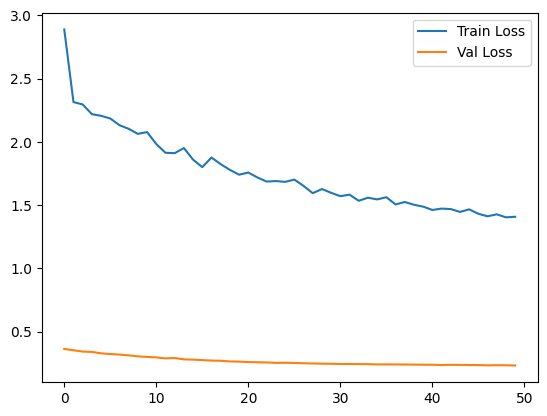

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val), 
    epochs=50, 
    batch_size=256, 
    callbacks=callbacks,
    verbose=1
)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

## 6. Prediction & Forecast Output

In [26]:
predictions = model.predict(X_val)
return_mean = scaler.mean_[-2]
return_std = scaler.scale_[-2]

def denormalize_returns(data):
    return (data * return_std) + return_mean

pred_returns = denormalize_returns(predictions)
last_price = df['Close'].iloc[-1]
last_timestamp = df.index[-1]

print("\n--- 5-MINUTE REAL-TIME FORECAST ---")
print(f"Market Data as of: {last_timestamp} UTC")
print("------------------------------------------")
for i in range(5):
    forecast_time = last_timestamp + timedelta(minutes=i+1)
    forecasted_return = pred_returns[-1, i]
    direction = "UP" if forecasted_return > 0 else "DOWN"
    projected_price = last_price * np.exp(forecasted_return)
    print(f"{forecast_time.strftime('%H:%M')} | {direction} | Target: {projected_price:.2f} USD")
    last_price = projected_price

final_change_pct = ((last_price / df['Close'].iloc[-1]) - 1) * 100
print("------------------------------------------")
print(f"Final Forecasted Change: {final_change_pct:+.4f}%")

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step

--- 5-MINUTE REAL-TIME FORECAST ---
Market Data as of: 2026-04-14 20:34:00 UTC
------------------------------------------
20:35 | UP | Target: 74241.35 USD
20:36 | DOWN | Target: 74230.53 USD
20:37 | UP | Target: 74235.64 USD
20:38 | UP | Target: 74240.07 USD
20:39 | DOWN | Target: 74230.10 USD
